## Computational Astrobiology – Project Results Jobs

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, max_error, explained_variance_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    classification_report
)

sns.set_theme(style="whitegrid")

### Data Loading & Column Inspection

In [2]:
INPUT_TRUTH    = 'data/newTruth.csv'
INPUT_FEATURES = 'data/newFeatures.csv'

t_df = pd.read_csv(INPUT_TRUTH)
f_df = pd.read_csv(INPUT_FEATURES)

df = pd.merge(t_df, f_df, on=['path', 'sim'], how='inner')

print("TRUTH COLUMNS (t_ = ground truth, p_ = derived truth / habitability components)")
print([c for c in df.columns if c.startswith('t_') or c.startswith('p_')])
print()
print("FEATURE COLUMNS (f_ = BLS/LC features, c_ = catalogue-derived features)")
print([c for c in df.columns if c.startswith('f_') or c.startswith('c_')])

TRUTH COLUMNS (t_ = ground truth, p_ = derived truth / habitability components)
['t_act_flare', 't_act_flare_amp', 't_act_flare_dur', 't_act_flare_per', 't_act_sigma', 't_act_spot', 't_act_tau', 't_planet', 't_planet_a', 't_planet_i', 't_planet_p', 't_planet_r', 'p_B', 'p_C', 'p_F', 'p_H', 'p_R', 'p_S', 'p_T', 'p_teq', 'p_xeff']

FEATURE COLUMNS (f_ = BLS/LC features, c_ = catalogue-derived features)
['f_best_depth', 'f_best_duration', 'f_best_initial', 'f_bls_num_actual', 'f_bls_num_expect', 'f_bls_num_ratio', 'f_bls_period_1st', 'f_bls_period_2nd', 'f_bls_period_3rd', 'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd', 'f_bls_snr', 'f_bls_trans_shape_fac', 'f_dens', 'f_density_ratio', 'f_dur_per_ratio', 'f_goodness_flag', 'f_lc_hi_1perc', 'f_lc_hi_5perc', 'f_lc_kurt', 'f_lc_lo_1perc', 'f_lc_lo_5perc', 'f_lc_mad', 'f_lc_rms', 'f_lc_skew', 'f_logg', 'f_lum', 'f_mag', 'f_mass', 'f_period_ratio_21', 'f_period_ratio_31', 'f_points_in_transit_ratio', 'f_radius', 'f_teff', 'c_R', 'c_S'

### Feature Configuration

In [3]:
# ── Hostility regressor (p_H) ─────────────────────────────────────────────────
FEATURES_H = [
    'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd',
    'f_bls_snr',
    'f_lc_hi_1perc', 'f_lc_hi_5perc',
]

RF_PARAMS_H = dict(n_estimators=100, max_depth=15, min_samples_leaf=1,
                   max_features='sqrt', random_state=123, n_jobs=-1)

# ── Radius regressor (p_R, logit-transformed) ─────────────────────────────────
FEATURES_R = [
    'f_best_depth', 'f_best_duration', 'f_best_initial',
    'f_bls_num_actual', 'f_bls_num_expect', 'f_bls_num_ratio',
    'f_bls_period_1st', 'f_bls_period_2nd', 'f_bls_period_3rd',
    'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd',
    'f_bls_snr', 'f_bls_trans_shape_fac',
    'f_dens', 'f_density_ratio', 'f_dur_per_ratio', 'f_goodness_flag',
    'f_lc_hi_1perc', 'f_lc_hi_5perc', 'f_lc_kurt',
    'f_lc_lo_1perc', 'f_lc_lo_5perc', 'f_lc_mad', 'f_lc_rms', 'f_lc_skew',
    'f_logg', 'f_lum', 'f_mag', 'f_mass',
    'f_period_ratio_21', 'f_period_ratio_31', 'f_points_in_transit_ratio',
    'f_radius', 'f_teff',
    'c_R', 'c_S', 'c_T', 'c_planet_a', 'c_planet_i', 'c_planet_r',
    'c_teq', 'c_xeff',
]

RF_PARAMS_R = dict(n_estimators=150, max_depth=10, min_samples_leaf=2,
                   max_features='sqrt', random_state=123, n_jobs=-1)

# ── Temperature / HZ regressor (p_T, logit-transformed) ──────────────────────
FEATURES_T = [
    'f_best_depth', 'f_best_duration',
    'f_bls_period_1st',
    'f_bls_power_1st',
    'f_bls_snr', 'f_bls_trans_shape_fac',
    'f_dur_per_ratio',
    'f_lc_hi_1perc', 'f_lc_hi_5perc', 'f_lc_kurt',
    'f_lc_lo_1perc', 'f_lc_lo_5perc', 'f_lc_mad', 'f_lc_rms', 'f_lc_skew',
    'f_points_in_transit_ratio',
    'c_T', 'c_teq', 'c_xeff',
]

RF_PARAMS_T = dict(n_estimators=100, max_depth=20, min_samples_leaf=15,
                   random_state=123, n_jobs=-1)

# ── Planet classifier (t_planet) ──────────────────────────────────────────────
FEATURES_C = [
    'f_lc_skew', 'f_bls_trans_shape_fac', 'f_best_duration',
    'f_density_ratio', 'f_best_depth', 'f_dur_per_ratio',
]

RF_PARAMS_C = dict(n_estimators=100, max_depth=3, min_samples_leaf=45,
                   max_features=None, class_weight='balanced',
                   random_state=123, n_jobs=-1)

# ── MLP outlier-flag ensemble ─────────────────────────────────────────────────
MLP_SEEDS      = [0, 1, 2, 3, 4]   # 5-member ensemble, one per seed
MLP_PARAMS = dict(hidden_layer_sizes=(64, 32), max_iter=10000, solver='lbfgs', random_state=0)
# std threshold above which a regression prediction is flagged as uncertain
MLP_STD_THRESH = 0.1

# ── General ───────────────────────────────────────────────────────────────────
TEST_SIZE   = 0.2
DUMP_DIR    = 'dump/'

### Helper Functions

In [4]:
def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def eval_regressor(y_test, y_pred, y_train, y_train_pred, X_train):
    """Print a standard regression evaluation table."""
    n, p = X_train.shape
    r2_tr = r2_score(y_train, y_train_pred)
    r2_te = r2_score(y_test,  y_pred)
    adj = lambda r2, n, p: 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"  MAE:            {mean_absolute_error(y_test, y_pred):.5f}")
    print(f"  MedAE:          {median_absolute_error(y_test, y_pred):.5f}")
    print(f"  RMSE:           {np.sqrt(mean_squared_error(y_test, y_pred)):.5f}")
    print(f"  Max error:      {max_error(y_test, y_pred):.5f}")
    print(f"  Train R²:       {r2_tr:.5f}  (adj {adj(r2_tr, n, p):.5f})")
    print(f"  Test  R²:       {r2_te:.5f}  (adj {adj(r2_te, len(y_test), p):.5f})")
    print(f"  Explained var:  {explained_variance_score(y_test, y_pred):.5f}")
    res = y_test - y_pred
    print(f"  Residual mean:  {np.mean(res):.5f}   std: {np.std(res):.5f}")


def plot_regressor(y_train, y_train_pred, y_test, y_pred,
                   label, r2_tr, r2_te, features, importances):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{label} — Diagnostics', fontsize=15, fontweight='bold')

    residuals = y_test - y_pred
    all_y = np.concatenate([y_train, y_test, y_train_pred, y_pred])
    lim = [all_y.min(), all_y.max()]

    # Actual vs predicted
    axes[0,0].scatter(y_train, y_train_pred, alpha=0.3, color='steelblue',
                      label=f'Train R²={r2_tr:.3f}')
    axes[0,0].scatter(y_test, y_pred, alpha=0.5, color='crimson',
                      label=f'Test  R²={r2_te:.3f}')
    axes[0,0].plot(lim, lim, 'k--', lw=1.5)
    axes[0,0].set(xlabel='Actual', ylabel='Predicted', title='Actual vs Predicted')
    axes[0,0].legend()

    # Residuals vs predicted
    axes[0,1].scatter(y_pred, residuals, alpha=0.5, color='purple')
    axes[0,1].axhline(0, color='k', linestyle='--', lw=1.5)
    axes[0,1].set(xlabel='Predicted', ylabel='Residual', title='Residuals vs Predicted')

    # Residual distribution
    sns.histplot(residuals, kde=True, ax=axes[1,0], color='teal', bins=30)
    axes[1,0].axvline(np.mean(residuals), color='red', linestyle=':', lw=2,
                      label=f'Mean={np.mean(residuals):.4f}')
    axes[1,0].set(xlabel='Residual', title='Residual Distribution')
    axes[1,0].legend()

    # Feature importances
    idx = np.argsort(importances)[::-1][:15]
    sns.barplot(x=importances[idx], y=[features[i] for i in idx],
                ax=axes[1,1], palette='viridis', legend=False,
                hue=[features[i] for i in idx])
    axes[1,1].set(xlabel='Importance', title='Top Features')

    plt.tight_layout()
    plt.show()


def train_rf_regressor(df_train, features, target, rf_params,
                       logit_transform=False, test_size=TEST_SIZE, label=''):
    """
    Train a RandomForestRegressor, print evaluation, show diagnostic plots.
    Returns (model, r2_test).
    """
    X = df_train[features]
    y_raw = df_train[target].values.ravel()

    if logit_transform:
        # drop logit-infinite boundary rows (p exactly 0 or 1)
        finite_mask = (y_raw > 1e-6) & (y_raw < 1 - 1e-6)
        X, y_raw = X[finite_mask], y_raw[finite_mask]
        y = logit(y_raw)
    else:
        y = y_raw

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size,
                                               random_state=42)
    model = RandomForestRegressor(**rf_params)
    model.fit(X_tr, y_tr)

    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    if logit_transform:
        print("  (trained on logit-transformed target; metrics are in logit space)")
    eval_regressor(y_te, y_te_pred, y_tr, y_tr_pred, X_tr)

    r2_tr = r2_score(y_tr, y_tr_pred)
    r2_te = r2_score(y_te, y_te_pred)
    plot_regressor(y_tr, y_tr_pred, y_te, y_te_pred,
                   label, r2_tr, r2_te, features, model.feature_importances_)
    return model, r2_te


def train_rf_classifier(df_train, features, target, rf_params,
                        test_size=TEST_SIZE, label=''):
    """
    Train a RandomForestClassifier, print evaluation, show diagnostic plots.
    Returns (model, roc_auc).
    """
    X = df_train[features]
    y = df_train[target].values.ravel()

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size,
                                               random_state=42)
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_tr)

    y_tr_pred  = model.predict(X_tr)
    y_te_pred  = model.predict(X_te)
    y_tr_prob  = model.predict_proba(X_tr)[:, 1]
    y_te_prob  = model.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, y_te_prob)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Train accuracy:  {accuracy_score(y_tr, y_tr_pred):.5f}")
    print(f"  Test  accuracy:  {accuracy_score(y_te, y_te_pred):.5f}")
    print(f"  Precision:       {precision_score(y_te, y_te_pred, zero_division=0):.5f}")
    print(f"  Recall:          {recall_score(y_te, y_te_pred, zero_division=0):.5f}")
    print(f"  F1:              {f1_score(y_te, y_te_pred, zero_division=0):.5f}")
    print(f"  ROC-AUC:         {auc:.5f}")
    print()
    print(classification_report(y_te, y_te_pred, zero_division=0))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{label} — Diagnostics', fontsize=15, fontweight='bold')

    cm = confusion_matrix(y_te, y_te_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar=False,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
    axes[0,0].set_title('Confusion Matrix')

    for split, fpr, tpr, auc_val in [
        ('Train', *roc_curve(y_tr, y_tr_prob)[:2], roc_auc_score(y_tr, y_tr_prob)),
        ('Test',  *roc_curve(y_te, y_te_prob)[:2], auc),
    ]:
        axes[0,1].plot(fpr, tpr, lw=2, label=f'{split} AUC={auc_val:.3f}')
    axes[0,1].plot([0,1],[0,1],'k--',lw=1)
    axes[0,1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0,1].legend(loc='lower right')

    sns.histplot(x=y_te_prob, hue=y_te, element='step', stat='density',
                 common_norm=False, kde=True, ax=axes[1,0], palette='coolwarm')
    axes[1,0].set(xlabel='P(planet)', title='Predicted Probability by Class')

    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1]
    sns.barplot(x=importances[idx], y=[features[i] for i in idx],
                ax=axes[1,1], palette='viridis', legend=False,
                hue=[features[i] for i in idx])
    axes[1,1].set(xlabel='Importance', title='Feature Importances')

    plt.tight_layout()
    plt.show()
    return model, auc


def build_mlp_uncertainty(df_train, features, target,
                          logit_transform=False,
                          seeds=MLP_SEEDS, mlp_params=MLP_PARAMS,
                          std_thresh=MLP_STD_THRESH, label=''):
    """
    Train a small ensemble of MLPs on the same data.
    Returns a function flag_outliers(df) -> (mean_pred, std_pred, is_uncertain)
    where predictions are always in the original [0,1] space.
    """
    X_all = df_train[features].values
    y_raw = df_train[target].values.ravel()

    if logit_transform:
        mask = (y_raw > 1e-6) & (y_raw < 1 - 1e-6)
        X_all, y_raw = X_all[mask], y_raw[mask]
        y_all = logit(y_raw)
    else:
        y_all = y_raw

    scaler = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ])
    scaler.fit(X_all)
    X_sc = scaler.transform(X_all)

    members = []
    for s in seeds:
        m = MLPRegressor(**{**mlp_params, 'random_state': s})
        m.fit(X_sc, y_all)
        members.append(m)

    def flag_outliers(df_inference):
        X_inf = scaler.transform(df_inference[features].values)
        preds = np.array([m.predict(X_inf) for m in members])  # (n_members, n_samples)
        if logit_transform:
            preds = sigmoid(preds)
        mean_pred = preds.mean(axis=0)
        std_pred  = preds.std(axis=0)
        uncertain = std_pred > std_thresh
        return mean_pred, std_pred, uncertain

    n_uncertain = flag_outliers(df_train)[2].sum()
    print(f"  [{label}] MLP ensemble trained. "
          f"Uncertain on training set (std>{std_thresh}): "
          f"{n_uncertain}/{len(df_train)} ({100*n_uncertain/len(df_train):.1f}%)")

    return flag_outliers

### Training Set & Model Training


  Hostility Regressor (p_H)
  MAE:            0.05375
  MedAE:          0.00326
  RMSE:           0.14270
  Max error:      0.73291
  Train R²:       0.96887  (adj 0.96839)
  Test  R²:       0.89390  (adj 0.88705)
  Explained var:  0.89513
  Residual mean:  0.01539   std: 0.14186


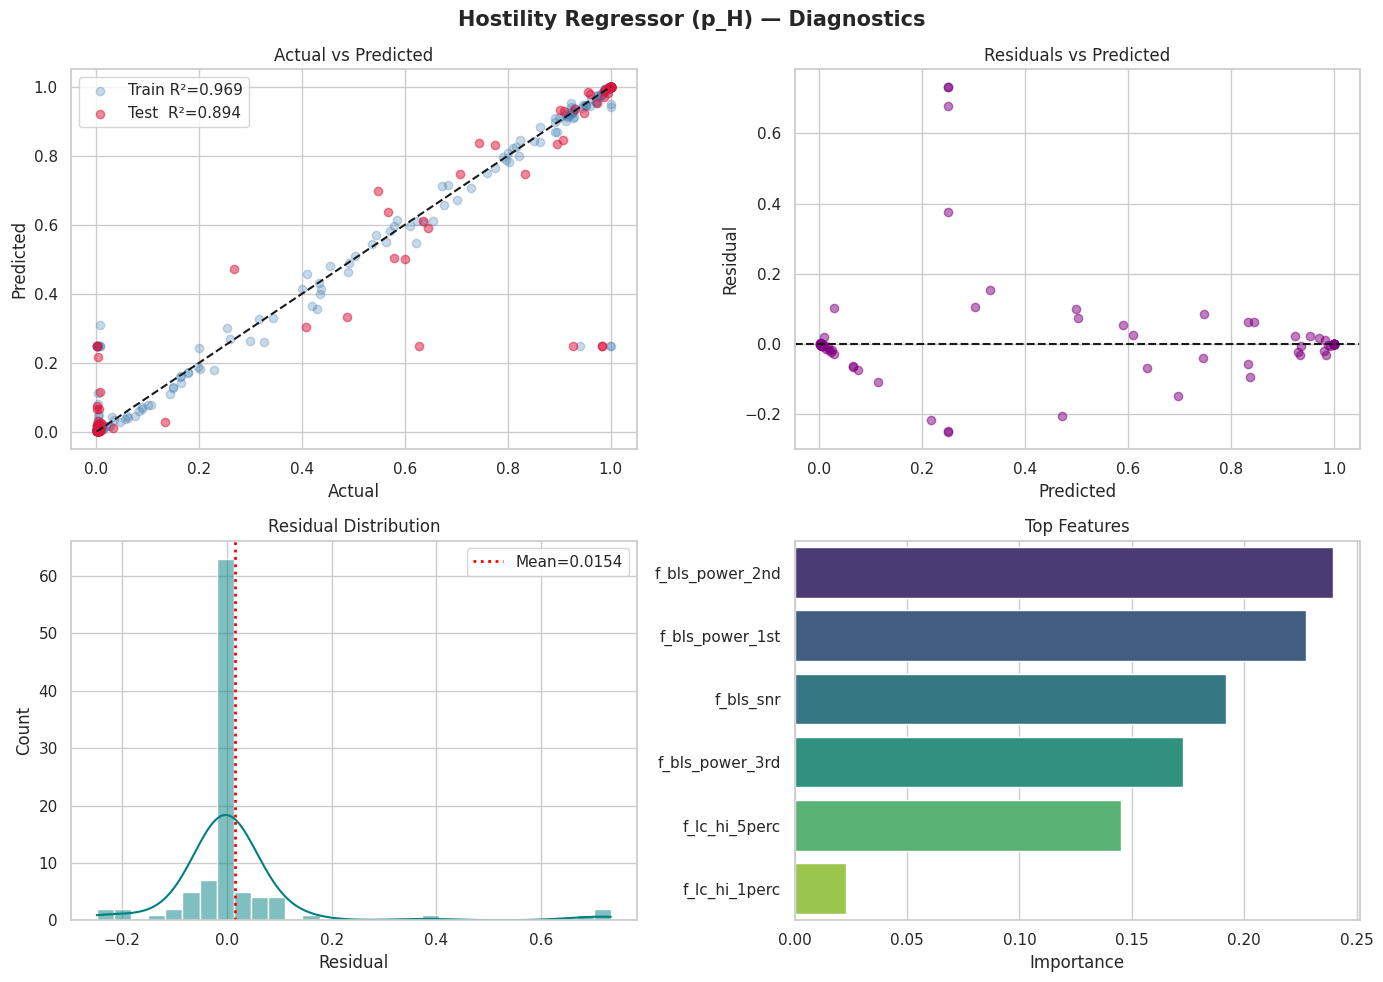


  Radius Regressor (p_R, logit)
  (trained on logit-transformed target; metrics are in logit space)
  MAE:            3.41499
  MedAE:          2.51432
  RMSE:           4.60224
  Max error:      14.99508
  Train R²:       0.67194  (adj 0.61413)
  Test  R²:       -0.12078  (adj -1.84197)
  Explained var:  -0.11011
  Residual mean:  0.44892   std: 4.58029


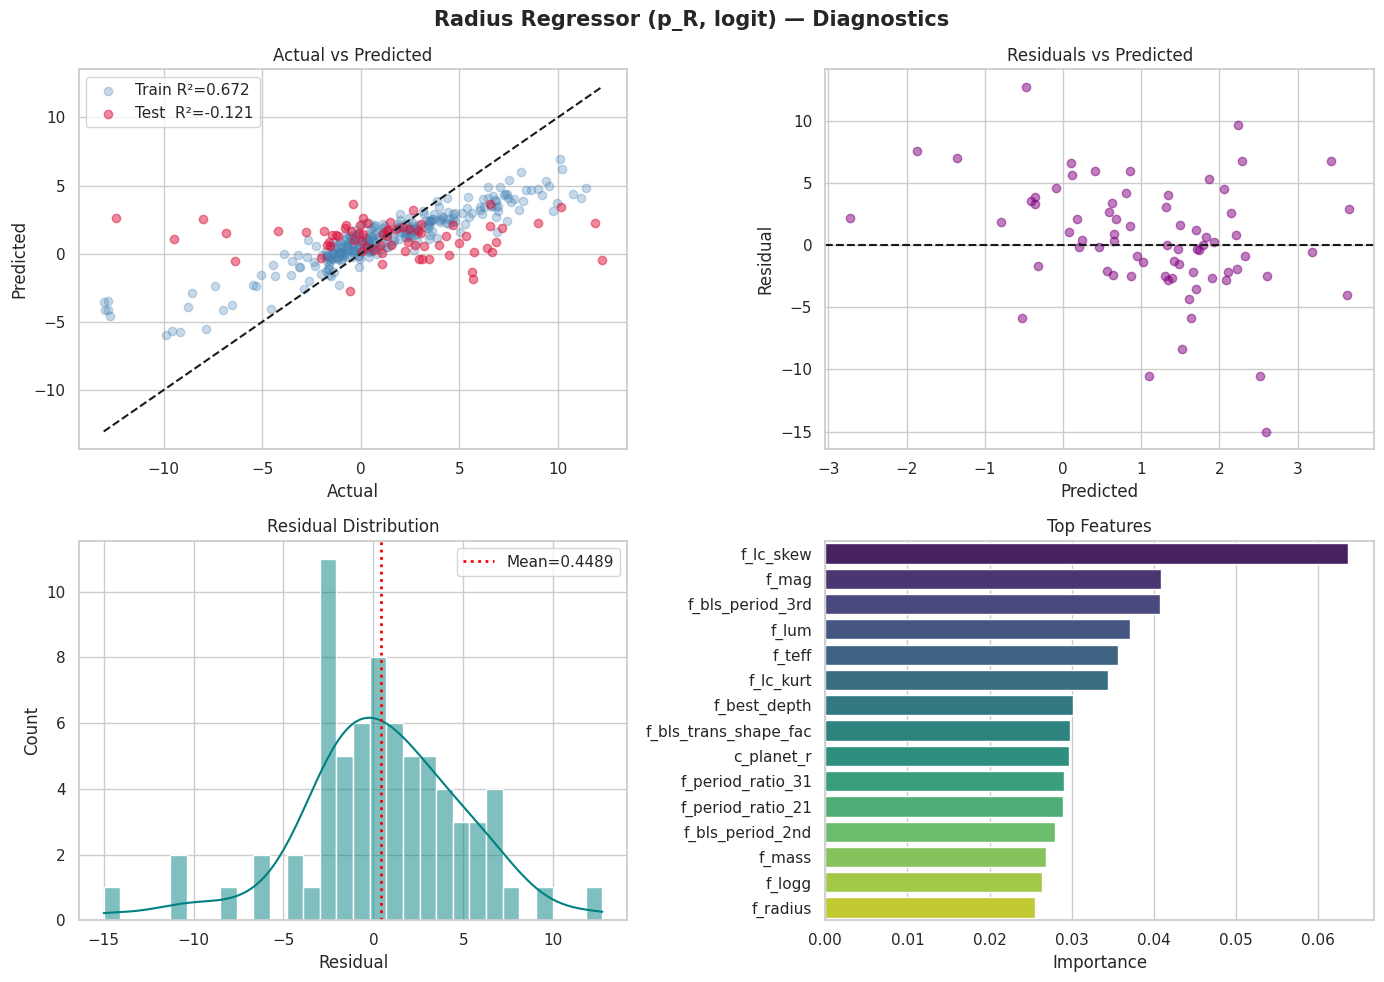


  Temperature / HZ Regressor (p_T, logit)
  (trained on logit-transformed target; metrics are in logit space)
  MAE:            4.82903
  MedAE:          4.77703
  RMSE:           5.63051
  Max error:      12.82555
  Train R²:       0.18253  (adj 0.08232)
  Test  R²:       0.15773  (adj -0.50906)
  Explained var:  0.16322
  Residual mean:  0.45461   std: 5.61213


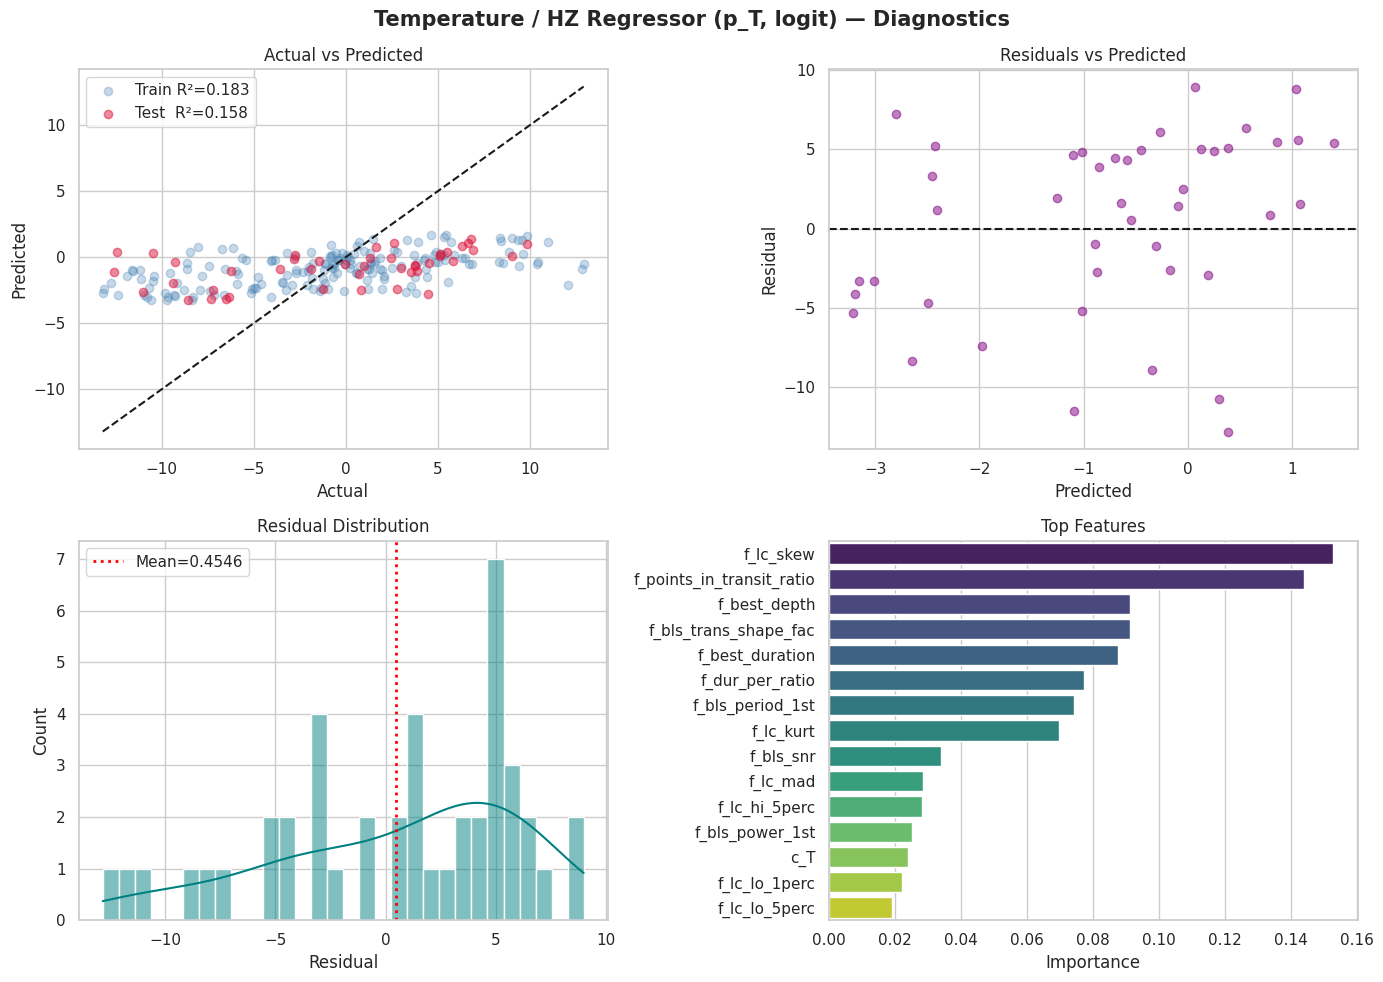


  Planet Classifier
  Train accuracy:  0.67375
  Test  accuracy:  0.58000
  Precision:       0.57143
  Recall:          0.50000
  F1:              0.53333
  ROC-AUC:         0.67223

              precision    recall  f1-score   support

           0       0.59      0.65      0.62       104
           1       0.57      0.50      0.53        96

    accuracy                           0.58       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.58      0.58      0.58       200



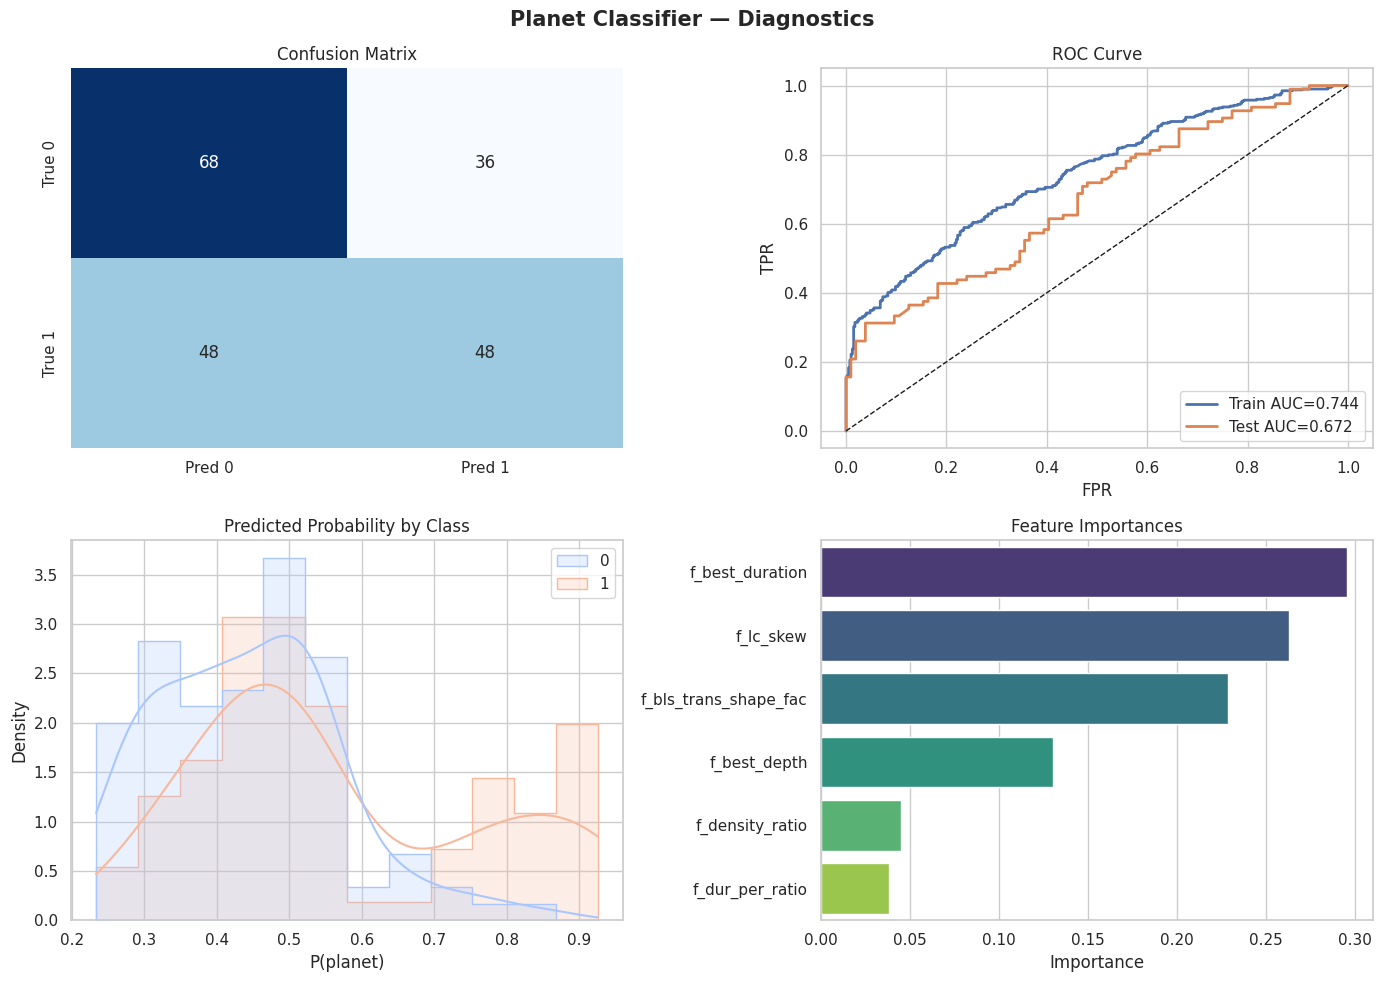

In [5]:
# Only rows with a confirmed planet, from training paths
train_df = df[(df['t_planet'] == 1) & (df['path'].str.contains('train'))].copy()

# ── Hostility ─────────────────────────────────────────────────────────────────
model_H, r2_H = train_rf_regressor(
    train_df, FEATURES_H, 'p_H', RF_PARAMS_H,
    logit_transform=False, label='Hostility Regressor (p_H)'
)

# ── Radius ────────────────────────────────────────────────────────────────────
model_R, r2_R = train_rf_regressor(
    train_df, FEATURES_R, 'p_R', RF_PARAMS_R,
    logit_transform=True, label='Radius Regressor (p_R, logit)'
)

# ── Temperature / HZ ─────────────────────────────────────────────────────────
model_T, r2_T = train_rf_regressor(
    train_df, FEATURES_T, 'p_T', RF_PARAMS_T,
    logit_transform=True, label='Temperature / HZ Regressor (p_T, logit)'
)

# ── Planet classifier ─────────────────────────────────────────────────────────
# Classifier uses all train/test paths (not restricted to t_planet==1)
full_train_df = df[df['path'].str.contains('train')].copy()
model_C, auc_C = train_rf_classifier(
    full_train_df, FEATURES_C, 't_planet', RF_PARAMS_C,
    label='Planet Classifier'
)

### Multilayer Perceptron Uncertainty Ensembles

In [6]:
flag_H = build_mlp_uncertainty(train_df, FEATURES_H, 'p_H',
                                logit_transform=False, label='H')
flag_R = build_mlp_uncertainty(train_df, FEATURES_R, 'p_R',
                                logit_transform=True,  label='R')
flag_T = build_mlp_uncertainty(train_df, FEATURES_T, 'p_T',
                                logit_transform=True,  label='T')

  [H] MLP ensemble trained. Uncertain on training set (std>0.1): 0/500 (0.0%)
  [R] MLP ensemble trained. Uncertain on training set (std>0.1): 89/500 (17.8%)
  [T] MLP ensemble trained. Uncertain on training set (std>0.1): 202/500 (40.4%)


### Dataset Inference & Composite Score

In [7]:
# ── Per-tree ensemble predictions (RF uncertainty estimates) ──────────────────
def rf_predict_with_std(model, X, logit_transform=False):
    preds = np.array([t.predict(X) for t in model.estimators_])
    if logit_transform:
        preds = sigmoid(preds)
    return preds.mean(axis=0), preds.std(axis=0)


X_all_H = df[FEATURES_H].values
X_all_R = df[FEATURES_R].values
X_all_T = df[FEATURES_T].values

df['m_H_mean'], df['m_H_std'] = rf_predict_with_std(model_H, X_all_H, logit_transform=False)
df['m_R_mean'], df['m_R_std'] = rf_predict_with_std(model_R, X_all_R, logit_transform=True)
df['m_T_mean'], df['m_T_std'] = rf_predict_with_std(model_T, X_all_T, logit_transform=True)

df['m_planet_prob'] = model_C.predict_proba(df[FEATURES_C])[:, 1]
df['m_planet_pred'] = model_C.predict(df[FEATURES_C])

# ── MLP uncertainty flags ─────────────────────────────────────────────────────
_, df['mlp_H_std'], df['mlp_H_uncertain'] = flag_H(df)
_, df['mlp_R_std'], df['mlp_R_uncertain'] = flag_R(df)
_, df['mlp_T_std'], df['mlp_T_uncertain'] = flag_T(df)

df['mlp_any_uncertain'] = df[['mlp_H_uncertain','mlp_R_uncertain','mlp_T_uncertain']].any(axis=1)

# ── Composite habitability score ──────────────────────────────────────────────
df['m_C'] = (0.5 * df['m_R_mean'] + 0.5 * df['m_T_mean']) * (1.0 - df['m_H_mean'])

print(f"Full dataset: {len(df)} rows")
print(f"MLP-flagged as uncertain (any component): {df['mlp_any_uncertain'].sum()}")

Full dataset: 1500 rows
MLP-flagged as uncertain (any component): 1142


### Save Models

In [8]:
joblib.dump(model_H, f'{DUMP_DIR}newScoreHostility.pkl')
joblib.dump(model_R, f'{DUMP_DIR}newScoreRadius.pkl')
joblib.dump(model_T, f'{DUMP_DIR}newScoreTemperature.pkl')
joblib.dump(model_C, f'{DUMP_DIR}newClass.pkl')
print("All models saved.")

All models saved.


### Results Inspection

High-confidence candidates: 7


,p_C,m_C,p_H,m_H_mean,m_H_std,p_R,m_R_mean,m_R_std,p_T,m_T_mean,m_T_std,m_planet_prob
1142,9.865108e-01,0.699746,0.003084,0.004280,0.002160,9.791737e-01,0.795713,0.291356,0.999951,0.609795,0.380406,0.865312
1096,7.108858e-01,0.686945,0.002368,0.003234,0.001364,4.268901e-01,0.640877,0.357130,0.998257,0.737473,0.331211,0.819093
1032,4.993339e-01,0.680886,0.001332,0.015199,0.027323,4.373637e-29,0.635238,0.366935,1.000000,0.747551,0.300507,0.854465
1236,1.991356e-01,0.612716,0.002614,0.004117,0.003151,0.000000e+00,0.735249,0.331444,0.399315,0.495249,0.405934,0.867602
1144,4.905349e-01,0.581275,0.000961,0.014306,0.028640,9.663686e-30,0.475337,0.411992,0.982014,0.704086,0.342360,0.804475
1050,4.008730e-01,0.471703,0.003896,0.016028,0.045292,3.680782e-43,0.307294,0.375281,0.804882,0.651478,0.363506,0.804475
1069,2.382575e-39,0.363746,0.002282,0.010481,0.034981,4.776048e-39,0.201960,0.328165,0.000000,0.533237,0.389287,0.810317


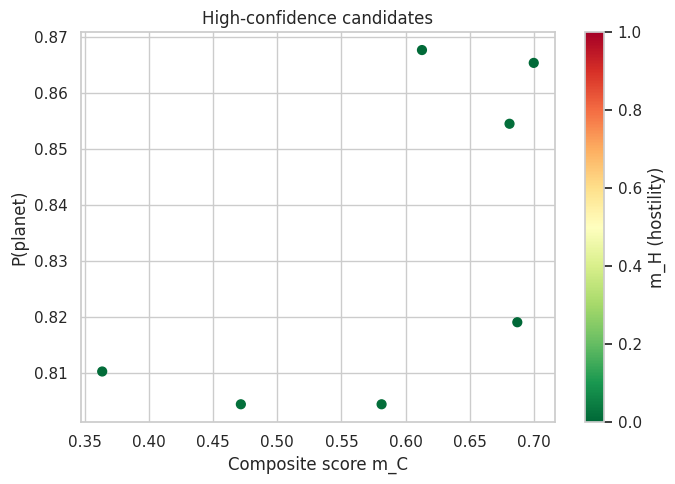

In [9]:
# High-confidence planet candidates from realistic data
mask = (
    df['path'].str.contains('real') &
    (df['m_planet_prob'] > 0.8) &
    (df['m_H_std'] < 0.1) &
    (~df['mlp_any_uncertain'])
)

result_cols = [
    'p_C', 'm_C',
    'p_H', 'm_H_mean', 'm_H_std',
    'p_R', 'm_R_mean', 'm_R_std',
    'p_T', 'm_T_mean', 'm_T_std',
    'm_planet_prob',
]

# only keep columns that actually exist for real observations
result_cols = [c for c in result_cols if c in df.columns]

results = df[mask][result_cols].sort_values('m_C', ascending=False)

print(f"High-confidence candidates: {len(results)}")
display(results.head(20))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(results['m_C'], results['m_planet_prob'],
           c=results['m_H_mean'], cmap='RdYlGn_r', vmin=0, vmax=1, s=40)
sc = ax.scatter([], [], c=[], cmap='RdYlGn_r', vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='m_H (hostility)')
ax.set(xlabel='Composite score m_C', ylabel='P(planet)',
       title='High-confidence candidates')
plt.tight_layout()
plt.show()